<a href="https://colab.research.google.com/github/arthireddy14/Deep_Learning/blob/main/mnist_dataset_cnn_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# load dataset
(x_train,y_train),(x_test,y_test)=mnist.load_data()

# display dataset shapes
print(f"x_train shape {x_train.shape}")
print(f"y_train shape {y_train.shape}")
print(f"x_test shape {x_test.shape}")
print(f"y_test shape {y_test.shape}")

x_train shape (60000, 28, 28)
y_train shape (60000,)
x_test shape (10000, 28, 28)
y_test shape (10000,)


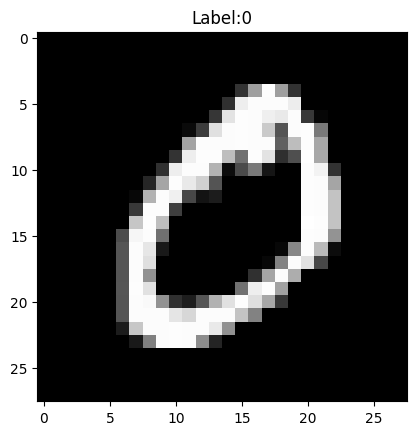

In [ ]:
# basic data visualization
img=x_train[1,:,:]
label=y_train[1]
plt.imshow(img,cmap='gray')
plt.title(f"Label:{label}")
plt.show()

# Data Preprocessing

Normalize the data and reshape it for CNN input

In [ ]:
# normalize and reshape
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float')/255

# one-hot encode labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

# Model Building

Build a CNN model using Keras Sequential API.

In [ ]:
model=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    # Convocation layer->detects the patterns
    MaxPooling2D(pool_size=(2,2)),
    # pooling layer->reduces spatial dimensions
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation
Compile the model with Adam optimizer and categorical crossentropy loss.

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# Model Training
Train the model on the training data

In [ ]:
histroy=model.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)
# epochs->model sees dataset 5 times
# batch_size->processes 128 images per step
# validation_split->uses 20% of training data for validation

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8381 - loss: 0.5431 - val_accuracy: 0.9795 - val_loss: 0.0756
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0677 - val_accuracy: 0.9840 - val_loss: 0.0561
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0428 - val_accuracy: 0.9843 - val_loss: 0.0514
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0347 - val_accuracy: 0.9884 - val_loss: 0.0409
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9881 - val_loss: 0.0418


# Model Evaluation
Evaluate the model on the test data.

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print(f"Test Loss:{test_loss}")
print(f"Test Accuracy:{test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9871 - loss: 0.0395
Test Loss:0.031674254685640335
Test Accuracy:0.9894000291824341


# Prediction
Make predictions on new data samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


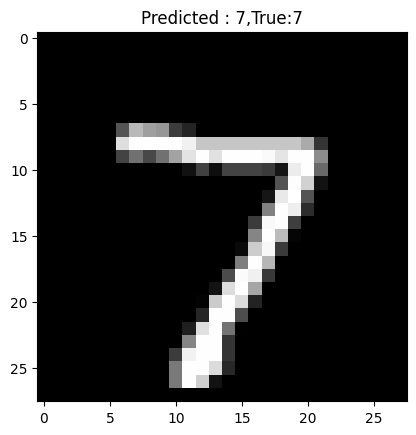

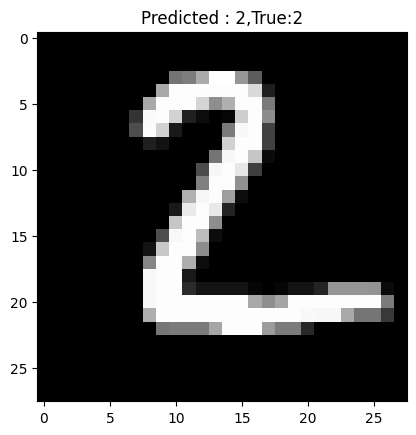

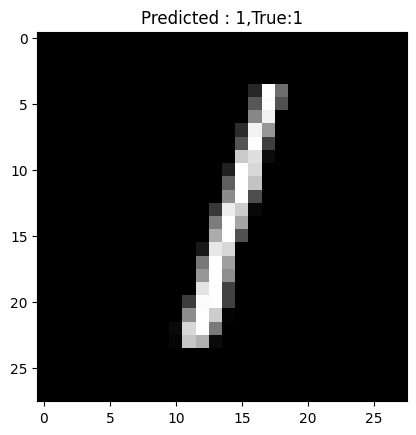

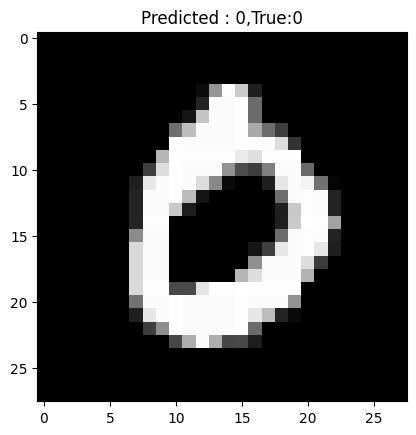

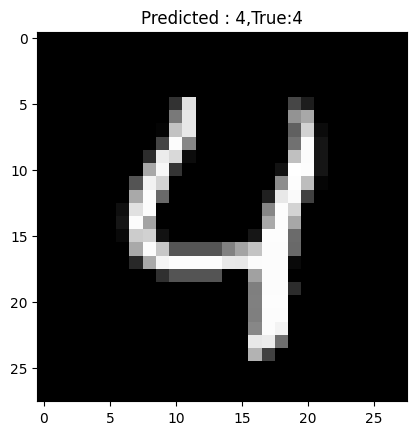

In [ ]:
# predict on few test samples
predictions=model.predict(x_test[:5])
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5],axis=1)

for i in range(5):
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Predicted : {predicted_classes[i]},True:{true_classes[i]}")
  plt.show()